In [36]:
import pandas as pd

In [37]:
df = pd.read_csv('./data/titanic.csv')

In [38]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
267,268,1,3,"Persson, Mr. Ernst Ulrik",male,25.0,1,0,347083,7.7750,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S
571,572,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S


In [39]:
print(f"El conjunto de datos contiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El conjunto de datos contiene 891 filas y 12 columnas.


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


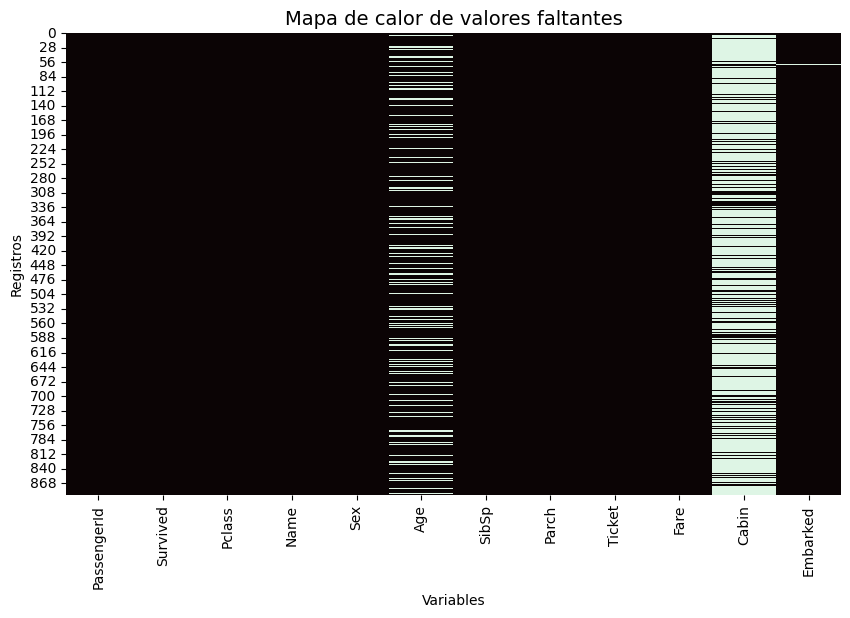

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='mako')
plt.title('Mapa de calor de valores faltantes', fontsize=14)
plt.xlabel('Variables')
plt.ylabel('Registros')
plt.show()


In [42]:
missing_percent = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing_percent



Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
dtype: float64

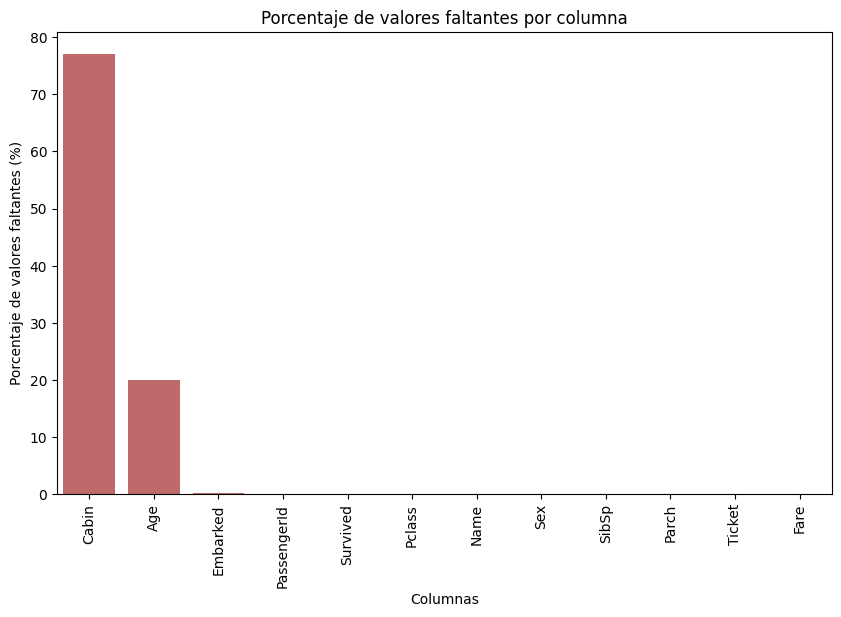

In [43]:
missing_percent = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values, color='indianred')
plt.title('Porcentaje de valores faltantes por columna')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje de valores faltantes (%)')
plt.xticks(rotation=90)
plt.show()


In [44]:
df = df.drop(columns=['Cabin'])


In [45]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)


In [46]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)


In [47]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


In [48]:
round(df.isnull().sum().sort_values(ascending=False) / len(df) * 100, 2)


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [49]:
(df.isnull().mean() * 100).round(2).sort_values(ascending=False)


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [50]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])


In [53]:
print(f"Después de limpiar el dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")


Después de limpiar el dataset: 891 filas y 8 columnas.


In [54]:
df.to_csv('./data/titanic_clean.csv', index=False)
